# WSU Education Abroad Data Analysis

**Analyst** Seohyeon Yoon
**Date** August 20th, 2025

This analysis explores trends in WSU Education Abroad from 2008 to 2025, examining participation over time, program types, academic outcomes, and destination patterns. After standardizing fields (e.g., year and major), engineering time bins, and addressing missing values where appropriate, I visualize the data through tables and charts with brief narratives. I then add a recent (2020–2025) snapshot and a policy-oriented equity view that compares regional access by college and major. The goal is not only to describe what happened, but to surface practical questions for planning, access, and program design.

## 1. About Education Abroad (Context)

**Vision**  
We promote positive lifelong global awareness and engagement for the WSU community.

**Mission**  
We present the WSU community with the tools to explore and understand one’s role in our global society. We commit to creating equitable opportunities for all identities to engage in global experiences. To this end, we provide a framework to develop global and international competencies, both on and off the WSU campuses. We believe this work is critical to the ongoing formation of a sustainable and peaceful world.

**Commitment to Diversity**  
We are committed to creating equitable opportunities for all identities within the WSU community to engage in global experiences.

source: https://ip.wsu.edu/education-abroad/

## 2. Quick Glossary

- **Exchange** – Students leaving WSU on bilateral exchange agreements  
- **Incoming** – Students coming to WSU on bilateral exchange agreements  
- **Faculty-Led** – Programs led by WSU faculty members and offering WSU credits  
- **Provider** – Students traveling with a third-party provider  
- **NAP/ITR/Direct Enroll** – Students traveling on one of our independent support options

## 3. Loading Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'GL all time data 07 24.csv'
df = pd.read_csv(file_path)

print("Initial Data Info:")
df.info()
print("\nSample Data:")
df.dropna().head()

Initial Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10925 entries, 0 to 10924
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Program                 10925 non-null  object 
 1   Program Type            10925 non-null  object 
 2   Academic Year           2043 non-null   object 
 3   App Cycle               10925 non-null  object 
 4   Preferred Pronouns      2120 non-null   object 
 5   Itinerary Start         8116 non-null   object 
 6   Location                7514 non-null   object 
 7   Country                 10925 non-null  object 
 8   Student Cumulative GPA  10387 non-null  float64
 9   Major                   10445 non-null  object 
 10  College                 374 non-null    object 
dtypes: float64(1), object(10)
memory usage: 939.0+ KB

Sample Data:


,Program,Program Type,Academic Year,App Cycle,Preferred Pronouns,Itinerary Start,Location,Country,Student Cumulative GPA,Major,College
484,Exchange ISEP Taiwan: Providence University,Exchange,22 - 23,Fall 2022,she/her/hers,08/31/2022,"Taichung City, Taiwan",Taiwan,3.88,Accounting,CAHNRS
485,"CEA-CAPA Czech Republic, Prague: Full Curricul...",Provider,23 - 24,Fall 2023,she/her/hers,08/28/2023,"Prague, Czech Republic",Czech Republic,3.29,Accounting,CAHNRS
503,"CEA CAPA France, French Riviera: SKEMA Busines...",Provider,22 - 23,Spring 2023,she/her/hers,01/03/2023,"Sophia Antipolis, France",France,3.74,Accounting,Business
504,"CEA CAPA France, French Riviera: SKEMA Busines...",Provider,22 - 23,Spring 2023,she/her/hers,01/03/2023,"Sophia Antipolis, France",France,3.18,Accounting,Business
505,"SAI Italy, Florence: Florence University of th...",Provider,22 - 23,Spring 2023,he/him/his,01/24/2023,"Florence, Italy",Italy,3.21,Accounting,Business


## 4. Cleaning Data

In [2]:
#Standardize columns 
work = df.copy()
work.columns = (work.columns
                  .str.strip()
                  .str.replace('/', ' ', regex=False)
                  .str.replace(r'[^0-9A-Za-z]+', '_', regex=True)
                  .str.replace(r'_+', '_', regex=True)
                  .str.strip('_')
                  .str.lower())

print("Cleaned column names:")
for col in work.columns:
    print("-", col)

Cleaned column names:
- program
- program_type
- academic_year
- app_cycle
- preferred_pronouns
- itinerary_start
- location
- country
- student_cumulative_gpa
- major
- college


In [3]:
# Build 'year' and 'year_bin' from App Cycle

# Extract numeric year from app_cycle (first 4-digit number found)
work['year'] = (work['app_cycle']
                  .astype(str)
                  .str.extract(r'(\d{4})')
                  .astype(float))

is_fall = work['app_cycle'].str.lower().str.startswith('fall', na=False)
work['year_academic'] = work['year'] + is_fall.astype(int)

# years into time periods
def year_bin(y):
    if pd.isna(y):
        return np.nan
    y = int(y)
    if 2008 <= y <= 2013:
        return '2008–2013'
    elif 2014 <= y <= 2019:
        return '2014–2019'
    elif 2020 <= y <= 2025:
        return '2020–2025'
    else:
        return 'Other'

work['year_bin'] = work['year_academic'].apply(year_bin)

print("Year bin counts:")
print(work['year_bin'].value_counts(dropna=False))
print("\nSample mapping:")
print(work[['app_cycle', 'year', 'year_academic', 'year_bin']].sample(10, random_state=1))


Year bin counts:
year_bin
2014–2019    4402
2008–2013    3756
2020–2025    2728
Other          39
Name: count, dtype: int64

Sample mapping:
        app_cycle    year  year_academic   year_bin
6482  Summer 2013  2013.0         2013.0  2008–2013
2802  Summer 2013  2013.0         2013.0  2008–2013
3568  Summer 2010  2010.0         2010.0  2008–2013
2811  Summer 2013  2013.0         2013.0  2008–2013
5029  Summer 2010  2010.0         2010.0  2008–2013
1308  Summer 2017  2017.0         2017.0  2014–2019
447   Spring 2025  2025.0         2025.0  2020–2025
7977  Summer 2010  2010.0         2010.0  2008–2013
9273  Spring 2011  2011.0         2011.0  2008–2013
6372  Spring 2025  2025.0         2025.0  2020–2025


In [4]:
# Impute GPA using mean
missing_before = work['student_cumulative_gpa'].isna().sum()

gpa_mean_global = work['student_cumulative_gpa'].mean()
work['student_cumulative_gpa'] = work['student_cumulative_gpa'].fillna(gpa_mean_global)

missing_after = work['student_cumulative_gpa'].isna().sum()

print(f"GPA global mean used for imputation: {gpa_mean_global}")
print(f"Missing GPA before: {missing_before}, after: {missing_after}")

GPA global mean used for imputation: 3.2792038124578795
Missing GPA before: 538, after: 0


In [5]:
import numpy as np

df["major_clean"] = (
    df["Major"].astype(str)
    .str.strip()   
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("&", "and")
    .str.replace("/", "and")
    .str.title()
)

# This TXT file contain one official major per line (from the WSU PDF)
official_list = pd.read_csv(
    r"majors.txt",
    header=None,
)[0].tolist()

def normalize(x):
    return (
        str(x).lower()
        .replace("&", "and")
        .replace("/", " ")
        .replace(",", " ")
        .replace(".", "")
        .replace("-", " ")
        .strip()
    )

# Create dictionary: normalized name -> official name
official_norm_map = {normalize(x): x for x in official_list}

# Create dictionary: prefix4 -> official name
def prefix4(x):
    return normalize(x)[:4] if pd.notnull(x) else None

official_prefix_map = {}
for major in official_list:
    key = prefix4(major)
    if key not in official_prefix_map:
        official_prefix_map[key] = major

# Apply mapping
df["major_std"] = (
    df["major_clean"]
    .map(lambda x: official_norm_map.get(normalize(x)))
)

df["major_std"] = df.apply(
    lambda row: row["major_std"] if pd.notnull(row["major_std"]) 
    else official_prefix_map.get(prefix4(row["major_clean"])),
    axis=1,
)

# Fill unmatched as "Other"
df["major_std"] = df["major_std"].fillna("Other")

print(df[["Major", "major_clean", "major_std"]].sample(20))
print(df.columns)
print(official_list[:10])


                          Major                  major_clean  \
8086                       MKTG                         Mktg   
8209                      MVTST                        Mvtst   
3606              Communication                Communication   
2187    Business Administration      Business Administration   
4332  Earth & Environmental Sci  Earth And Environmental Sci   
2239    Business Administration      Business Administration   
3026    Business Administration      Business Administration   
3014    Business Administration      Business Administration   
5580  Genetics and Cell Biology    Genetics And Cell Biology   
4313                        DTC                          Dtc   
3865              Communication                Communication   
563                  Accounting                   Accounting   
2169                   Business                     Business   
6451          Human Development            Human Development   
1751              Asian Studies         

In [6]:
# Print unique "Other" majors
others = df.loc[df["major_std"] == "Other", "major_clean"].unique().tolist()
print(f"Total {len(others)} 'Other' majors\n")
for i, x in enumerate(others, 1):
    print(f"{i}. {x}")

Total 157 'Other' majors

1. Nan
2. Adolescence
3. Ag And Food Business Economics
4. Ag Tech And Prod Management
5. Applied Economics
6. Applied Economics, M.S.
7. Art Ba
8. As St
9. Ash##
10. Ash56
11. Asian Studies
12. Ath T
13. Athletic Training
14. Athletic Training (Ath Tr)
15. B A
16. B E
17. Baem
18. Bio C
19. Busad
20. Cltrl Stdies Scial Thght Edu
21. Crm J
22. Crop Science
23. Crop Science, M.S.
24. Crop Science, Ph.D.
25. Crops
26. Cst M
27. Cultural
28. Curriculum And Instruct, M.A.
29. Curriculum And Instruction
30. Diet, Nutr, And Exr Phys, M.S.
31. Doctor Of Medicine
32. Dtc
33. E E
34. Early Childhood Education
35. Editing And Publishing
36. Education
37. Engineering And Tech Mgt, Metm
38. Envr And Ntrl Res Sci, Ph.D.
39. Espec
40. Evolutionary
41. Executive Mba
42. F A
43. F S
44. Family Nurse Practitioner-Pb
45. Family Studies
46. Fcmgt
47. Fin
48. Fine Arts
49. Fine Arts, M.F.A.
50. Forgn Languages Cltres, M.A.
51. Fshn
52. Game Studies And Design
53. Gen B
54. Gen H


In [7]:
# Manual mapping for all 159 unmapped labels
manual_map = {
    "Nan": "Other",  # 1
    "Adolescence": "Human Development",  # 2
    "Ag And Food Business Economics": "Agricultural and Food Business Economics",  # 3
    "Ag Tech And Prod Management": "Agricultural Technology and Production Management",  # 4
    "Applied Economics": "Economic Sciences",  # 5
    "Applied Economics, M.S.": "Economic Sciences",  # 6
    "Art Ba": "Art",  # 7
    "As St": "Social Studies",  # 8
    "Ash##": "Other",  # 9
    "Ash56": "Other",  # 10
    "Asian Studies": "Other",  # 11
    "Ath T": "Other",  # 12
    "Athletic Training": "Kinesiology",  # 13
    "Athletic Training (Ath Tr)": "Kinesiology",  # 14
    "B A": "Other",  # 15
    "B E": "Other",  # 16
    "Baem": "Other",  # 17
    "Bio C": "Biology",  # 18
    "Busad": "Business Administration",  # 19
    "Cltrl Stdies Scial Thght Edu": "Comparative Ethnic Studies",  # 20
    "Communication": "Integrated Strategic Communication",  # 21
    "Crm J": "Criminal Justice and Criminology",  # 22
    "Crop Science": "Field Crop Management",  # 23
    "Crop Science, M.S.": "Field Crop Management",  # 24
    "Crop Science, Ph.D.": "Field Crop Management",  # 25
    "Crops": "Field Crop Management",  # 26
    "Cst M": "Other",  # 27
    "Cultural": "Comparative Ethnic Studies",  # 28
    "Curriculum And Instruct, M.A.": "Elementary Education",  # 29
    "Curriculum And Instruction": "Elementary Education",  # 30
    "Diet, Nutr, And Exr Phys, M.S.": "Nutrition and Exercise Physiology",  # 31
    "Doctor Of Medicine": "Pharmaceutical and Medical Sciences",  # 32
    "Dtc": "Digital Technology and Culture",  # 33
    "E E": "Electrical Engineering",  # 34
    "Early Childhood Education": "Elementary Education",  # 35
    "Editing And Publishing": "English",  # 36
    "Education": "Elementary Education",  # 37
    "Engineering And Tech Mgt, Metm": "Management",  # 38
    "Envr And Ntrl Res Sci, Ph.D.": "Environmental and Ecosystem Sciences",  # 39
    "Espec": "Other",  # 40
    "Evolutionary": "Biology",  # 41
    "Executive Mba": "Business Administration",  # 42
    "F A": "Art",  # 43
    "F S": "Food Science",  # 44
    "Family Nurse Practitioner-Pb": "Nursing",  # 45
    "Family Studies": "Human Development",  # 46
    "Fcmgt": "Other",  # 47
    "Fin": "Finance",  # 48
    "Fine Arts": "Art",  # 49
    "Fine Arts, M.F.A.": "Art",  # 50
    "Forgn Languages Cltres, M.A.": "English",  # 51
    "Fshn": "Apparel Merchandising Design and Textiles",  # 52
    "Game Studies And Design": "Digital Technology and Culture",  # 53
    "Gen B": "Other",  # 54
    "Gen H": "Other",  # 55
    "Gen I": "Other",  # 56
    "Gen L": "Other",  # 57
    "Gen P": "Other",  # 58
    "Gen S": "Other",  # 59
    "Gencb": "Other",  # 60
    "Genms": "Other",  # 61
    "Geol": "Earth Sciences",  # 62
    "Geology": "Earth Sciences",  # 63
    "Ger": "Other",  # 64
    "Global Animal Health": "Animal Sciences",  # 65
    "Global Competencies": "Other",  # 66
    "Global Leadership": "Other",  # 67
    "Grad-Univ Idaho Coop Non-Deg": "Other",  # 68
    "Graphic Design": "Art",  # 69
    "H D": "Human Development",  # 70
    "H Fit": "Kinesiology",  # 71
    "Hbm": "Hospitality Business Management",  # 72
    "Health And Fitness": "Kinesiology",  # 73
    "Hort": "Horticulture",  # 74
    "Horticulture": "Horticulture",  # 75
    "I Bus": "International Business",  # 76
    "I D": "Interior Design",  # 77
    "Immunology Infectious Diseases": "Microbiology",  # 78
    "Ind": "Other",  # 79
    "Individual Interdisciplinary": "Other",  # 80
    "Information Systems": "Management Information Systems",  # 81
    "Journalism And Media Produc": "Media Innovation",  # 82
    "Journalism And Media Production": "Media Innovation",  # 83
    "L A": "Humanities",  # 84
    "Language, Literacy, And Techno": "Elementary Education",  # 85
    "Linguistics": "English",  # 86
    "M E": "Mechanical Engineering",  # 87
    "Marketing": "Business Administration",  # 88
    "Mgtop": "Management",  # 89
    "Mindfulness-Based Intelligence": "Other",  # 90
    "Mis": "Management Information Systems",  # 91
    "Mktg": "Marketing",  # 92
    "Molecular Plant Sciences": "Biology",  # 93
    "Mperf": "Music Performance",  # 94
    "Mse": "Materials Science and Engineering",  # 95
    "Multimedia Journalism": "Media Innovation",  # 96
    "Mus": "Music",  # 97
    "Mvtst": "Kinesiology",  # 98
    "Natrs": "Environmental and Ecosystem Sciences",  # 99
    "Natural Res Sciences, M.S.": "Environmental and Ecosystem Sciences",  # 100
    "Natural Resource Sciences": "Environmental and Ecosystem Sciences",  # 101
    "Nep": "Nutrition and Exercise Physiology",  # 102
    "Non Degree": "Other",  # 103
    "Non Degree Univ Idaho Ugrd": "Other",  # 104
    "Non-Certified": "Other",  # 105
    "Non-Certified Post Bacc": "Other",  # 106
    "Old Agriculture Andfood Security": "Agricultural and Food Business Economics",  # 107
    "Old Business Administration": "Business Administration",  # 108
    "Old Computer Science Ba": "Computer Science",  # 109
    "Old Fine Arts Ba": "Art",  # 110
    "Old Fine Arts Bfa": "Art",  # 111
    "Old Media And Technology": "Digital Technology and Culture",  # 112
    "Old Natural Resource Sci": "Environmental and Ecosystem Sciences",  # 113
    "Old Risk And Crisis Comm": "Risk and Crisis Communication",  # 114
    "Old Sport Science": "Kinesiology",  # 115
    "Plant Biology": "Biology",  # 116
    "Plant Pathology, M.S.": "Agricultural Biotechnology",  # 117
    "Pol S": "Political Science",  # 118
    "Pr La": "Other",  # 119
    "Pre-Occupational Therapy": "Kinesiology",  # 120
    "Pre-Pharmacy": "Pharmaceutical and Medical Sciences",  # 121
    "Pre-Physical Therapy": "Kinesiology",  # 122
    "Pre-Physician Assistant": "Kinesiology",  # 123
    "Prevention Science, Ph.D.": "Public Health",  # 124
    "Pub A": "Public Affairs",  # 125
    "Science Communication": "Integrated Strategic Communication",  # 126
    "Sciencechelor Of": "Other",  # 127
    "Shs": "Speech and Hearing Sciences",  # 128
    "So St": "Social Studies",  # 129
    "Soc": "Sociology",  # 130
    "Soil Science": "Earth Sciences",  # 131
    "Soil Science, Ph.D.": "Earth Sciences",  # 132
    "Special Education": "Elementary Education",  # 133
    "Specl": "Special Education",  # 134
    "Spmgt": "Sport Management",  # 135
    "Ss Sp": "Other",  # 136
    "Strategic Communication": "Integrated Strategic Communication",  # 137
    "Strategic Communication, M.A.": "Integrated Strategic Communication",  # 138
    "Study Abroad": "Other",  # 139
    "Sustainable Agriculture, Gc": "Other",  # 140
    "Tcert": "Other",  # 141
    "Teaching And Learning, Ed.M.": "Elementary Education",  # 142
    "Teaching And Learning, Mit": "Elementary Education",  # 143
    "Teaching And Learning, Ph.D.": "Elementary Education",  # 144
    "Teaching Elementary": "Elementary Education",  # 145
    "Teaching English Foreign Lang": "English",  # 146
    "Teaching Secondary": "Social Studies",  # 147
    "Theat": "Theatre Arts",  # 148
    "Theatre Arts And Drama": "Theatre Arts",  # 149
    "Undecided Graduate": "Other",  # 150
    "Undecided Undergraduate": "Other",  # 151
    "Veterinary Medicine": "Animal Sciences",  # 152
    "Veterinary Medicine (Ut)": "Animal Sciences",  # 153
    "Veterinary Medicine Mt": "Animal Sciences",  # 154
    "Veterinary Science, Ph.D.": "Animal Sciences",  # 155
    "W St": "Women's Gender and Sexuality Studies",  # 156
    "Water Resources Science And Mgt": "Environmental and Ecosystem Sciences",  # 157
    "Wbm": "Wine and Beverage Business Management",  # 158
    "Wecol": "Wildlife Ecology and Conservation Sciences",
    "Communication": "Communication" # 159
}

df["major_std"] = df["major_std"].replace(manual_map)

print(df[["Major","major_clean","major_std"]].sample(20, random_state=7))
print("\nStill Other:", df["major_std"].eq("Other").sum())
print(df.loc[df["major_std"]=="Other", "major_clean"].value_counts().to_string())


                        Major              major_clean  \
3559            Communication            Communication   
6935          Interior Design          Interior Design   
2641  Business Administration  Business Administration   
9504               Psychology               Psychology   
9269                    PSYCH                    Psych   
9594               Psychology               Psychology   
3841            Communication            Communication   
8279             Neuroscience             Neuroscience   
5944                  History                  History   
6496        Human Development        Human Development   
3999         Computer Science         Computer Science   
5225                  Finance                  Finance   
9578               Psychology               Psychology   
5275                  Finance                  Finance   
5129                  Finance                  Finance   
2467  Business Administration  Business Administration   
1628    Archit

In [8]:
manual_map_other = {
    "Veterinary Medicine": "Animal Sciences",
    "Pol S": "Political Science",
    "Mgtop": "Hospitality Business Management",
    "Mktg": "Marketing",
    "Fin": "Finance",
    "Strategic Communication": "Integrated Strategic Communication",
    "Soc": "Sociology",
    "Crm J": "Criminal Justice and Criminology",
    "Ag And Food Business Economics": "Agricultural and Food Business Economics",
    "Plant Biology": "Biology",
    "Busad": "Business Administration",
    "Old Computer Science Ba": "Computer Science"
}

df.loc[df["major_std"]=="Other", "major_std"] = \
    df.loc[df["major_std"]=="Other", "major_clean"].map(manual_map_other).fillna("Other")
print("\nStill Other:", df["major_std"].eq("Other").sum())
print(df.loc[df["major_std"]=="Other", "major_clean"].value_counts().to_string())



Still Other: 2155
major_clean
Nan                                 480
Undecided Undergraduate             284
Hbm                                 155
I Bus                               143
Non Degree                          122
Education                           117
Gen S                                68
Multimedia Journalism                36
Mis                                  36
Global Leadership                    32
Sciencechelor Of                     32
H D                                  31
I D                                  30
B A                                  27
L A                                  25
Gen H                                24
Shs                                  23
M E                                  20
F A                                  20
Ss Sp                                19
Global Competencies                  18
Mvtst                                16
Fine Arts                            16
Natural Resource Sciences            15
Non-Certi

In [9]:
print("Columns in cleaned dataset:")
print(work.columns.tolist())

print("Columns in df:", df.columns.tolist())

print("\nSample rows from cleaned dataset:")
print(work.sample(10, random_state=42))

Columns in cleaned dataset:
['program', 'program_type', 'academic_year', 'app_cycle', 'preferred_pronouns', 'itinerary_start', 'location', 'country', 'student_cumulative_gpa', 'major', 'college', 'year', 'year_academic', 'year_bin']
Columns in df: ['Program', 'Program Type', 'Academic Year', 'App Cycle', 'Preferred Pronouns', 'Itinerary Start', 'Location', 'Country', 'Student Cumulative GPA', 'Major', 'College', 'major_clean', 'major_std']

Sample rows from cleaned dataset:
                                                 program    program_type  \
2271        Faculty-Led Italy: OMBA in Rome and Florence     Faculty Led   
8698   Faculty-Led Peru: Healthcare in Peru - Communi...     Faculty Led   
3753   API Italy, Florence: Lorenzo de' Medici - Seme...        Provider   
8665           WSU Student International Travel Registry  NAP/ITR/Direct   
4441   IPSL Greece: Study, Service & Research Program...        Provider   
7868     Exchange Bilateral Sweden: Linköping University        E

## 5. Analyzing Data

### 5.1 Participation Over Time

Participation by Academic Year
   year_academic  count
0         2007.0     38
1         2008.0    513
2         2009.0    573
3         2010.0    582
4         2011.0    731


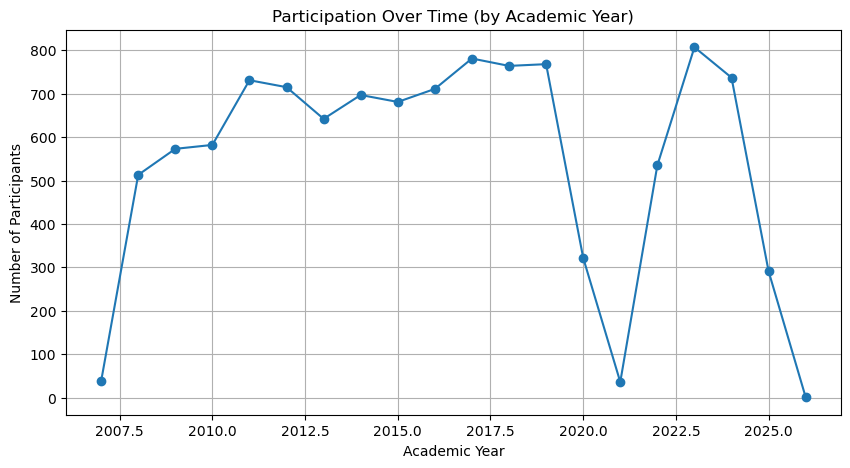

Participation by Year Bin
    year_bin  count
0  2008–2013   3756
1  2014–2019   4402
2  2020–2025   2728
3      Other     39


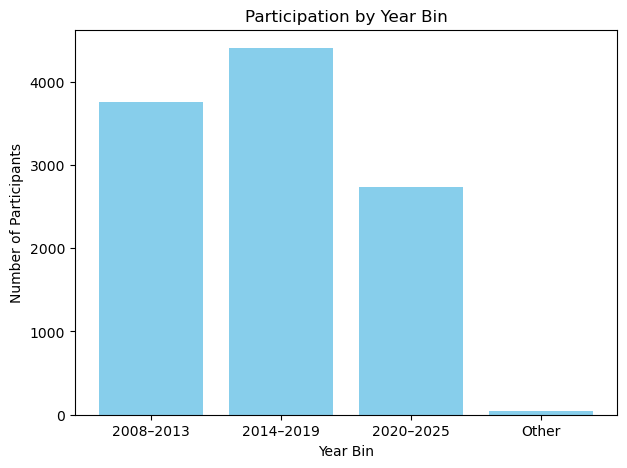

In [10]:
df = work.copy()

# Participation by year
participation_year = df.groupby("year_academic").size().reset_index(name="count")

# Table output
print("Participation by Academic Year")
print(participation_year.head())

# Line chart
plt.figure(figsize=(10,5))
plt.plot(participation_year["year_academic"], participation_year["count"], marker="o")
plt.title("Participation Over Time (by Academic Year)")
plt.xlabel("Academic Year")
plt.ylabel("Number of Participants")
plt.grid(True)
plt.show()

# Participation by year bin
participation_bin = df.groupby("year_bin").size().reset_index(name="count")

# Table output
print("Participation by Year Bin")
print(participation_bin)

# Bar chart (year bin)
plt.figure(figsize=(7,5))
plt.bar(participation_bin["year_bin"], participation_bin["count"], color="skyblue")
plt.title("Participation by Year Bin")
plt.xlabel("Year Bin")
plt.ylabel("Number of Participants")
plt.show()

**Insights**

- Participation in study abroad programs shows steady growth from 2008 through the late 2010s, peaking around 2018–2019.

- The sharp decline around 2020–2021 aligns with the COVID-19 pandemic, which significantly disrupted international travel and academic exchanges.

- After 2022, participation began to recover, though the levels are not yet as high as the pre-pandemic peak.

- By year bins, 2014–2019 recorded the highest number of participants, followed by 2008–2013. The 2020–2025 period shows lower participation, largely due to pandemic disruptions, though recent years suggest signs of recovery.

### 5.2 Participant characteristics

#### 5.2.1 Program Type Distribution (overall + by year bin)

Program Type — Overall
     program_type  count
1     Faculty Led   5101
4        Provider   4149
0        Exchange    637
3  NAP/ITR/Direct    619
2        Incoming    419


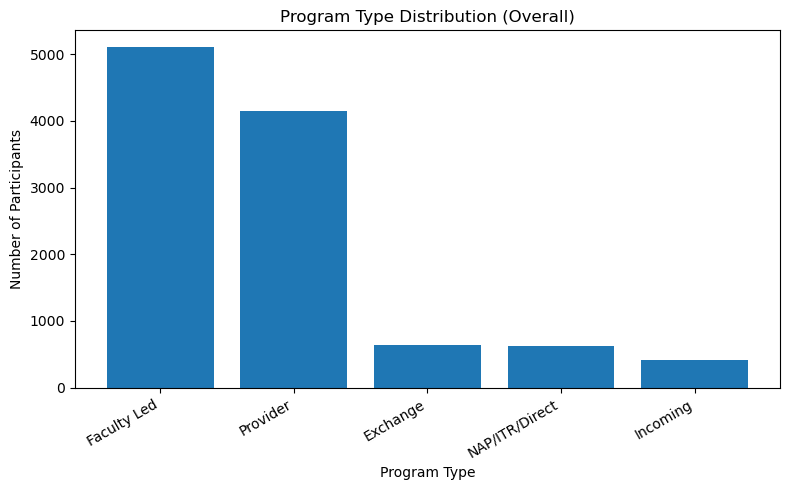


Program Type by Year Bin (counts)
program_type  Exchange  Faculty Led  Incoming  NAP/ITR/Direct  Provider
year_bin                                                               
2008–2013          233         1653       100             163      1607
2014–2019          191         2377       138             141      1555
2020–2025          188         1071       181             313       975


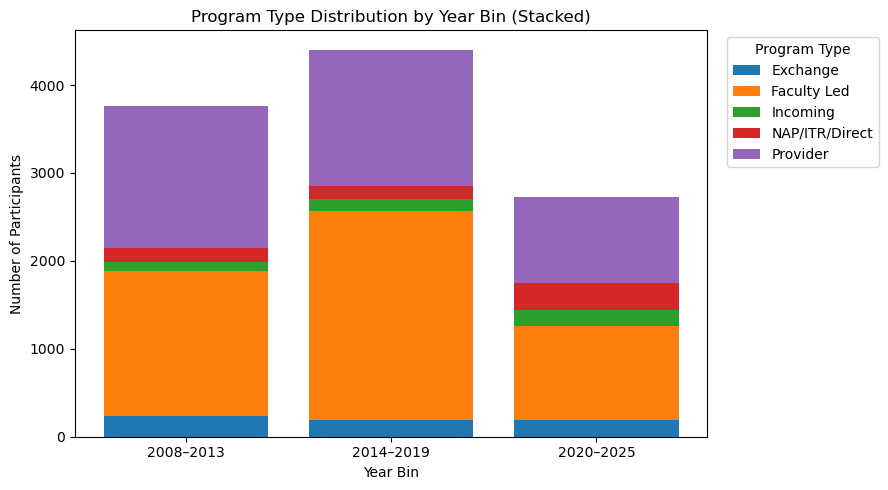

In [11]:
# Overall program type distribution
pt = (
    df.dropna(subset=["program_type"])
      .groupby("program_type")
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

print("Program Type — Overall")
print(pt)

plt.figure(figsize=(8,5))
plt.bar(pt["program_type"], pt["count"])
plt.title("Program Type Distribution (Overall)")
plt.xlabel("Program Type")
plt.ylabel("Number of Participants")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Stacked bars by year_bin
order_bins = ["2008–2013", "2014–2019", "2020–2025"]
pt_yb = (
    df.dropna(subset=["program_type", "year_bin"])
      .groupby(["year_bin", "program_type"])
      .size()
      .unstack(fill_value=0)
      .reindex(order_bins)
)

print("\nProgram Type by Year Bin (counts)")
print(pt_yb)

plt.figure(figsize=(9,5))
bottom = None
for col in pt_yb.columns:
    if bottom is None:
        plt.bar(pt_yb.index.astype(str), pt_yb[col], label=col)
        bottom = pt_yb[col].values
    else:
        plt.bar(pt_yb.index.astype(str), pt_yb[col], bottom=bottom, label=col)
        bottom = bottom + pt_yb[col].values
plt.title("Program Type Distribution by Year Bin (Stacked)")
plt.xlabel("Year Bin")
plt.ylabel("Number of Participants")
plt.legend(title="Program Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Insights**
- Faculty-Led and Provider programs dominate participation, making up the majority across all time periods.

- Exchange, Incoming, and NAF/IF/Direct programs remain relatively small in scale compared to the two dominant types.

- The distribution by year bin shows that Provider programs were especially strong in earlier years (2008–2013), while Faculty-Led gained more prominence in recent periods.

#### 5.2.2 Participation by Major

Participation by Major (using 'major') — Top 20
                              major  count
43          Business Administration    895
54                    Communication    544
144       Hospitality Business Mgmt    378
252                      Psychology    299
295         Undecided Undergraduate    284
182                       Marketing    273
5                        Accounting    232
39                          Biology    217
212                         Nursing    216
14                     Anthropology    204
106                         Finance    198
44   Business Administration, M.B.A    194
159          International Business    186
156                 Interior Design    177
15    Apparel Merch Design Textiles    174
146               Human Development    157
137                             HBM    155
244               Political Science    153
254                Public Relations    151
148                           I BUS    143


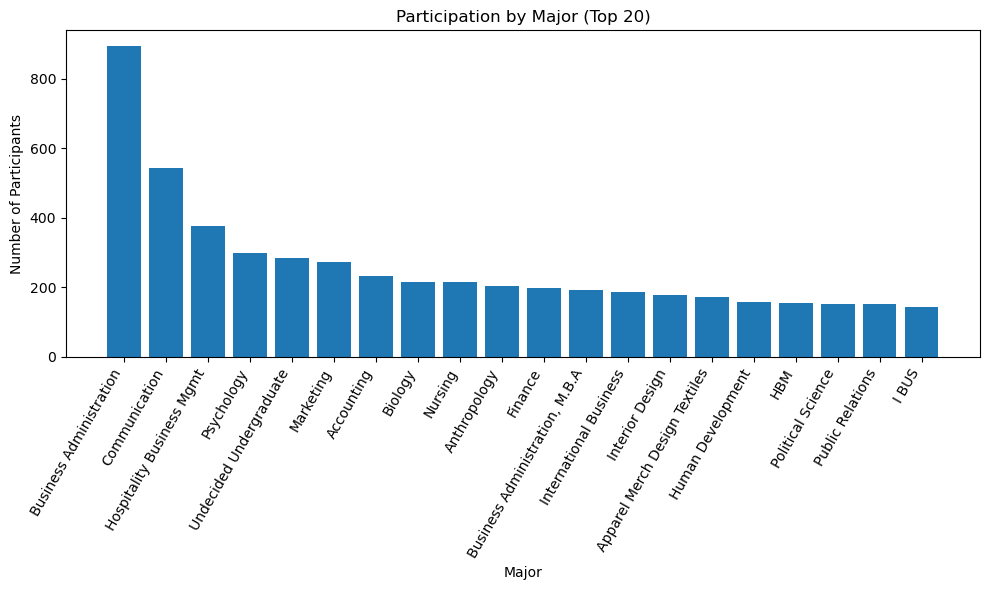

In [12]:
major_col = "major_std" if "major_std" in df.columns else "major"

maj_tbl = (
    df.dropna(subset=[major_col])
      .groupby(major_col)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

print(f"Participation by Major (using '{major_col}') — Top 20")
print(maj_tbl.head(20))

topM = 20
plot_maj = maj_tbl.head(topM)

plt.figure(figsize=(10,6))
plt.bar(plot_maj[major_col], plot_maj["count"])
plt.title(f"Participation by Major (Top {topM})")
plt.xlabel("Major")
plt.ylabel("Number of Participants")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()



**Insight**

- Business Administration is by far the largest major represented, followed by Communication and Hospitality/Business tracks.

- Psychology, Nursing, and Economics are also strong contributors, reflecting both social sciences and professional programs.

- A “long tail” of majors exists, where participation is spread across diverse academic disciplines, but at smaller scales.

### 5.3 Geographic distribution

#### 5.3.1 Top Locations & Countries

Top Countries (by participants)
            country  count
59            Italy   1662
99            Spain   1542
114  United Kingdom    603
47           Greece    464
49        Guatemala    450
22            China    444
41           France    430
111             USA    419
43          Germany    353
86             Peru    334
103     Switzerland    315
61            Japan    307
25       Costa Rica    297
57          Ireland    292
6         Australia    281


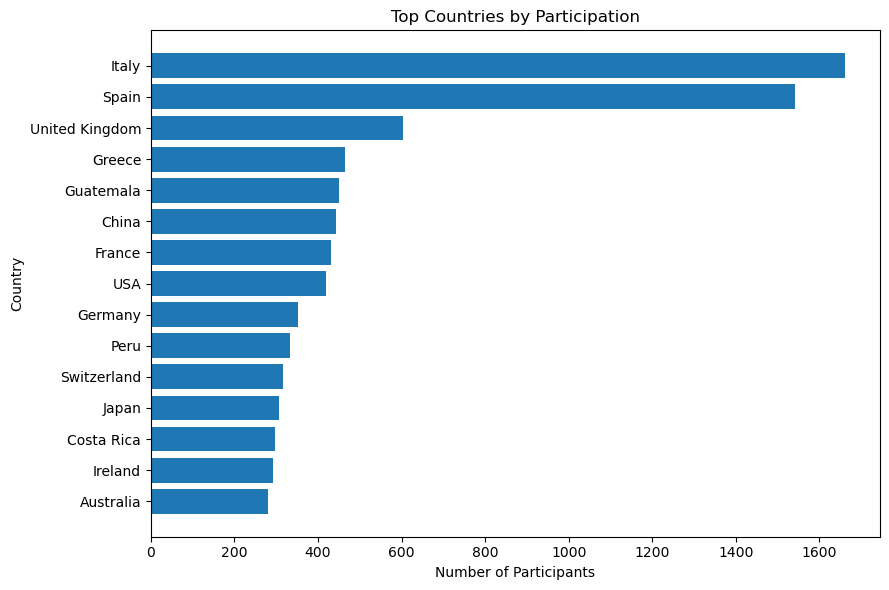


Top Locations (first listed city)
                      location  count
120            Florence, Italy    897
34            Barcelona, Spain    584
23              Athens, Greece    358
55           Brig, Switzerland    247
362     Travel Day, Travel Day    219
266              Paris, France    215
206     London, United Kingdom    185
32           Bangkok, Thailand    178
404          Zacapa, Guatemala    162
295                Rome, Italy    154
95                 Cusco, Peru    146
144  Guatemala City, Guatemala    141
108            Dublin, Ireland    141
321             Seville, Spain    131
319         Seoul, South Korea    125


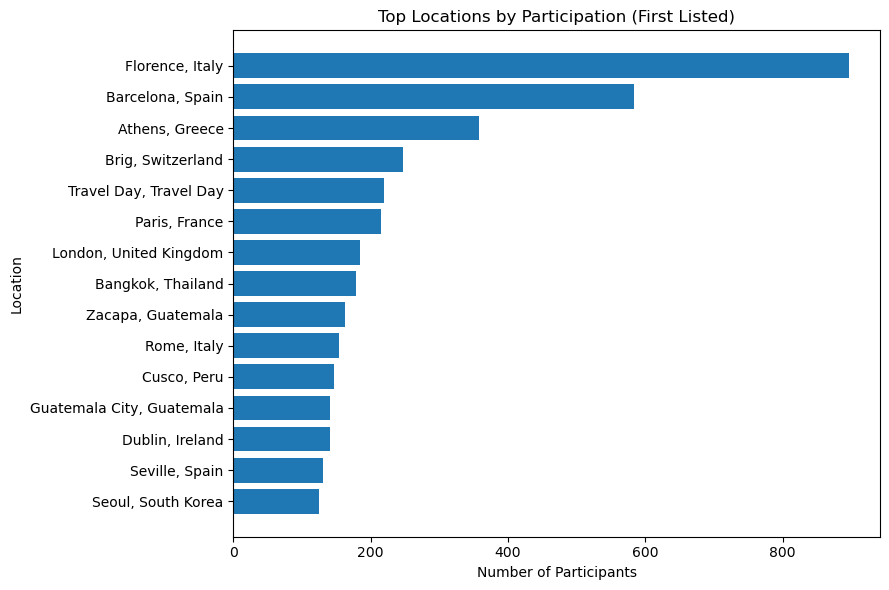

In [13]:
# Top countries
topN_countries = 15
countries_tbl = (
    df.dropna(subset=["country"])
      .groupby("country")
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)
print("Top Countries (by participants)")
print(countries_tbl.head(topN_countries))

plt.figure(figsize=(9,6))
plot_c = countries_tbl.head(topN_countries)
plt.barh(plot_c["country"][::-1], plot_c["count"][::-1])
plt.title("Top Countries by Participation")
plt.xlabel("Number of Participants")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Top locations
loc_first = (
    df["location"]
    .dropna()
    .astype(str)
    .str.split(";").str[0].str.strip()
)
locations_tbl = (
    loc_first.groupby(loc_first)
             .size()
             .reset_index(name="count")
             .sort_values("count", ascending=False)
)
topN_locations = 15
print("\nTop Locations (first listed city)")
print(locations_tbl.head(topN_locations))

plt.figure(figsize=(9,6))
plot_l = locations_tbl.head(topN_locations)
plt.barh(plot_l.iloc[::-1, 0], plot_l.iloc[::-1, 1])
plt.title("Top Locations by Participation (First Listed)")
plt.xlabel("Number of Participants")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

**Insights**
- Countries: Italy and Spain dominate participation, far ahead of others (both ~1,500+ students). The UK, Greece, and Guatemala form a second tier, while destinations like Japan, Costa Rica, and Australia attract smaller groups.

- Cities: Florence (Italy) and Barcelona (Spain) are clear hubs, with Athens and Switzerland’s Brig also standing out. European capitals (Paris, London, Rome) remain consistently popular.

- There is a strong European bias, especially toward Mediterranean destinations. A small number of cities attract the bulk of students, which may indicate concentration in well-established partner institutions/programs.

#### 5.3.2 Program Type x Country

Program Type × Country (Top Countries)
program_type    Exchange  Faculty Led  Incoming  NAP/ITR/Direct  Provider
country                                                                  
Italy                 15          660         0              20       967
Spain                 47          597         0              20       878
United Kingdom       118          157         0              23       305
Greece                 0          431         0               4        29
Guatemala              0          379         0              71         0
China                 11          299         0              13       121
France                50          170         0              12       198
USA                    0            0       419               0         0


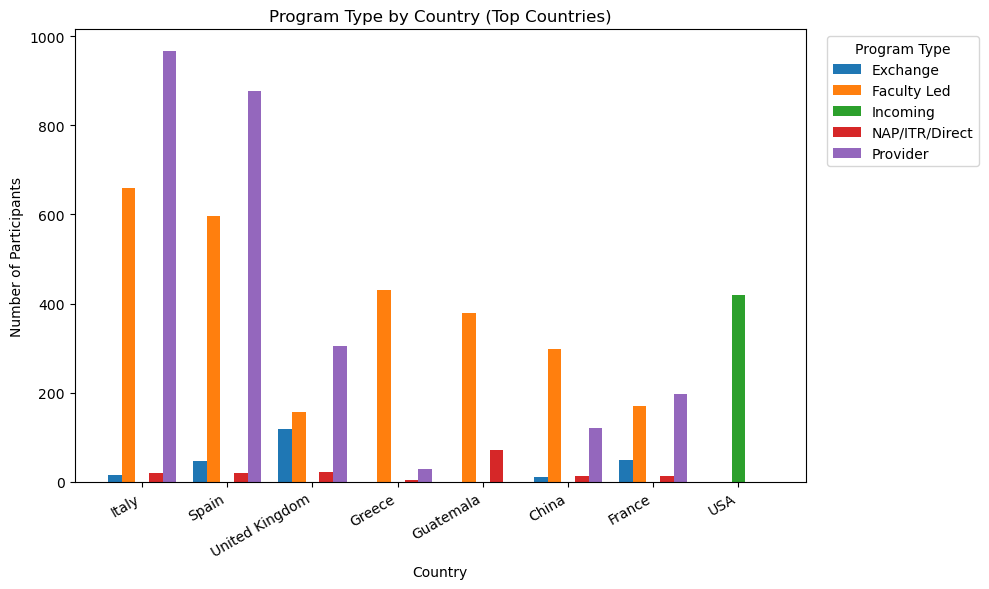

In [14]:
# Choose top countries by total count to keep the chart readable
topC = countries_tbl.head(8)["country"].tolist()

pt_country = (
    df[df["country"].isin(topC)]
    .dropna(subset=["program_type"])
    .groupby(["country", "program_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=topC)
)

print("Program Type × Country (Top Countries)")
print(pt_country)

# Clustered bar chart
x = np.arange(len(pt_country.index))
cols = list(pt_country.columns)
width = 0.8 / max(len(cols), 1)

plt.figure(figsize=(10,6))
for i, col in enumerate(cols):
    plt.bar(x + i*width, pt_country[col].values, width, label=col)
plt.xticks(x + width*(len(cols)-1)/2, pt_country.index, rotation=30, ha="right")
plt.title("Program Type by Country (Top Countries)")
plt.xlabel("Country")
plt.ylabel("Number of Participants")
plt.legend(title="Program Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Insights**
- Italy and Spain show high participation through Provider and Faculty-led programs.

- The UK has more Exchange participants than most other countries.

- Guatemala is mainly associated with Faculty-led programs, while the USA is unique for Incoming students.

- Program type distribution is destination-specific. Europe leans heavily on provider-led/faculty-led structures, while countries like the USA reflect inbound participation patterns.

#### 5.3.3 Major × Country

Major × Country (Top countries × Top majors) — counts
major           Business Administration  Communication  \
country                                                  
Italy                              96.0          122.0   
Spain                             292.0           94.0   
United Kingdom                     16.0           74.0   
Greece                             90.0            9.0   
Guatemala                           1.0            3.0   
China                              72.0            5.0   
France                             13.0           19.0   
USA                                 NaN            NaN   

major           Hospitality Business Mgmt  Marketing  Psychology  \
country                                                            
Italy                               152.0       85.0        60.0   
Spain                                38.0       77.0        68.0   
United Kingdom                        2.0        9.0        36.0   
Greece                   

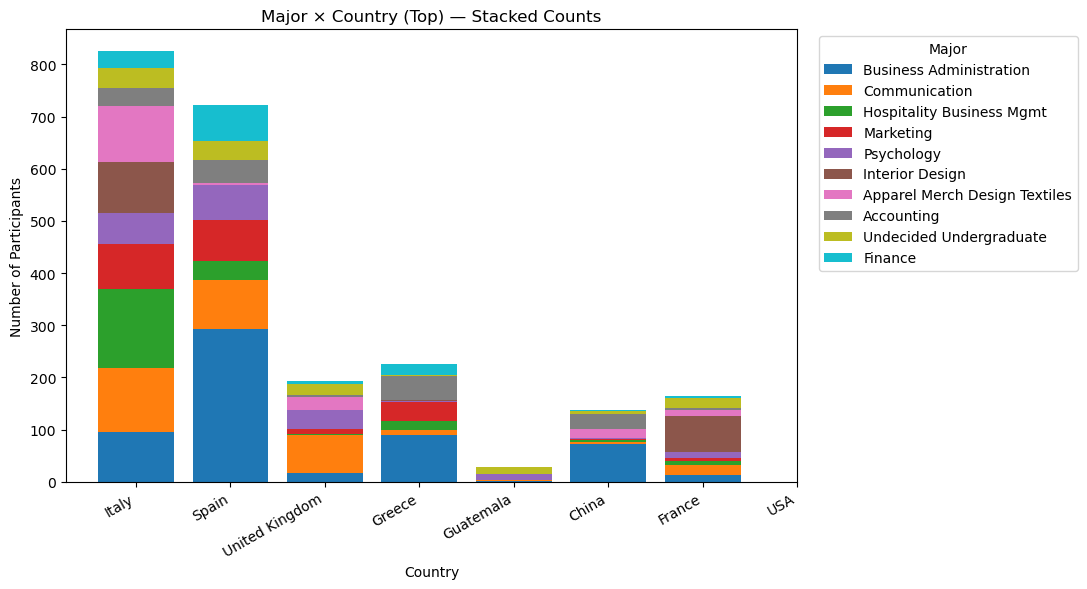

In [15]:
top_countries = countries_tbl.head(8)["country"].tolist()

countries_tbl = (
    df.dropna(subset=["country"])
      .groupby("country")
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

major_col = "major_std" if "major_std" in df.columns else "major"
top_majors = (
    df[df["country"].isin(top_countries)][major_col]
      .dropna().value_counts().head(10).index.tolist()
)

# pivot: counts of majors per country
maj_country_bar = (
    df[df["country"].isin(top_countries) & df[major_col].isin(top_majors)]
      .groupby(["country", major_col])
      .size()
      .unstack(fill_value=0)
      .reindex(index=top_countries, columns=top_majors)
)

print("Major × Country (Top countries × Top majors) — counts")
print(maj_country_bar)

# stacked bar chart
plt.figure(figsize=(11,6))
bottom = np.zeros(len(maj_country_bar))
x = np.arange(len(maj_country_bar.index))
for m in maj_country_bar.columns:
    vals = maj_country_bar[m].values
    plt.bar(x, vals, bottom=bottom, label=m)
    bottom += vals

plt.xticks(x, maj_country_bar.index, rotation=30, ha="right")
plt.title("Major × Country (Top) — Stacked Counts")
plt.xlabel("Country")
plt.ylabel("Number of Participants")
plt.legend(title="Major", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Insights**
- Italy and Spain dominate participation volumes, with Italy slightly ahead. These two destinations account for the bulk of study abroad activity.

- Business Administration is consistently strong across most countries, but especially in Spain and Greece.

- Hospitality Business Management stands out in Italy, making Italy the most popular destination for that major.

- Interior Design and Apparel/Textiles have a large share in Italy, suggesting strong alignment with Italy’s cultural/academic reputation in design and fashion.

- Spain shows more variety in majors compared with Italy while Business still leads, Communication, Psychology, and Finance are also significant contributors.

- Other countries (UK, Greece, Guatemala, China, France) show smaller participation but still reveal distinct patterns. e.g., UK with Communication, Greece with Business/Marketing, France with Interior Design.

- Italy = design/fashion + hospitality hub, Spain = business + broad mix, while other destinations remain niche but with recognizable academic alignments.

#### 5.3.4 Regional Bias (continent-level aggregation)

Region distribution (overall)
          region  count
0         Europe   6320
1  Latin America   1561
2           Asia   1438
3          Other    544
4  North America    501
5        Oceania    395
6         Africa    166

Region × Year Bin (counts)
region     Africa  Asia  Europe  Latin America  North America  Oceania  Other
year_bin                                                                     
2008–2013      73   666    1949            555            114      209    190
2014–2019      48   513    2594            758            142      122    225
2020–2025      45   252    1751            248            245       61    126


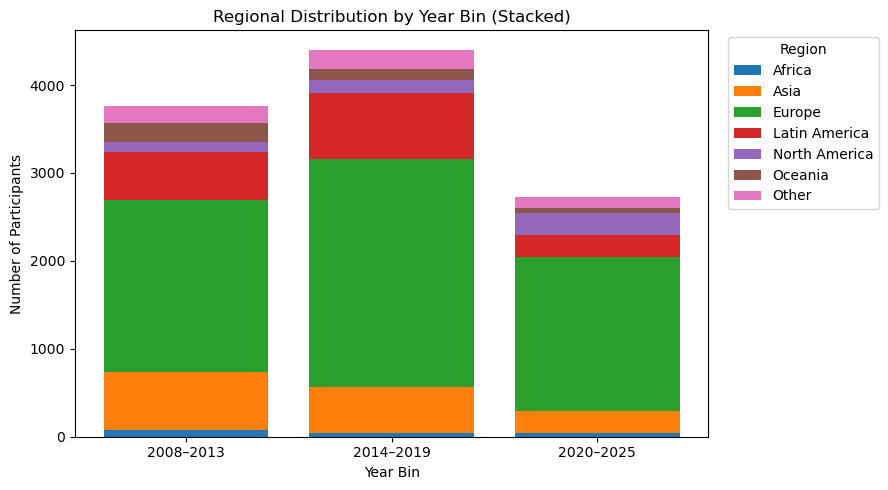

In [16]:
# Map countries to regions/continents
EUROPE = {
    "Italy","France","Spain","Germany","United Kingdom","UK","Ireland","Sweden","Norway","Denmark",
    "Finland","Netherlands","Belgium","Switzerland","Austria","Portugal","Greece","Czech Republic",
    "Poland","Hungary","Croatia"
}
ASIA = {
    "Japan","South Korea","Korea, South","Republic of Korea","China","Taiwan","Thailand","Vietnam",
    "Indonesia","Philippines","Singapore","Malaysia","India","Nepal","Sri Lanka","Turkey","Israel","Jordan","United Arab Emirates","UAE"
}
NORTH_AMERICA = {"United States","USA","Canada"}
LATIN_AMERICA = {
    "Mexico","Costa Rica","Peru","Guatemala","Panama","Belize","Honduras","Nicaragua","El Salvador",
    "Dominican Republic","Puerto Rico","Cuba","Colombia","Ecuador","Chile","Argentina","Brazil","Uruguay","Paraguay","Bolivia"
}
AFRICA = {"South Africa","Morocco","Kenya","Tanzania","Ghana","Rwanda","Uganda","Egypt","Namibia","Botswana","Ethiopia"}
OCEANIA = {"Australia","New Zealand","Fiji"}

def to_region(country: str) -> str:
    if not isinstance(country, str):
        return "Other"
    c = country.strip()
    if c in EUROPE: return "Europe"
    if c in ASIA: return "Asia"
    if c in NORTH_AMERICA: return "North America"
    if c in LATIN_AMERICA: return "Latin America"
    if c in AFRICA: return "Africa"
    if c in OCEANIA: return "Oceania"
    return "Other"

df["region"] = df["country"].apply(to_region)

# Overall region distribution
region_tbl = (
    df["region"].value_counts(dropna=False)
      .rename_axis("region").reset_index(name="count")
)
print("Region distribution (overall)")
print(region_tbl)

# Stacked by year_bin
order_bins = ["2008–2013", "2014–2019", "2020–2025"]
reg_yb = (
    df.dropna(subset=["year_bin"])
      .groupby(["year_bin","region"])
      .size()
      .unstack(fill_value=0)
      .reindex(order_bins)
)

print("\nRegion × Year Bin (counts)")
print(reg_yb)

plt.figure(figsize=(9,5))
bottom = None
for col in reg_yb.columns:
    vals = reg_yb[col].values
    if bottom is None:
        plt.bar(reg_yb.index.astype(str), vals, label=col)
        bottom = vals
    else:
        plt.bar(reg_yb.index.astype(str), vals, bottom=bottom, label=col)
        bottom = bottom + vals
plt.title("Regional Distribution by Year Bin (Stacked)")
plt.xlabel("Year Bin")
plt.ylabel("Number of Participants")
plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Insights**
- Europe dominates across all year bins, accounting for the majority of participants.

- Latin America and Asia consistently attract smaller but steady numbers.

- Africa and Oceania remain marginal destinations.

- Participation drops after 2020 in all regions, consistent with COVID-era travel disruptions.

- Study abroad participation is heavily Eurocentric, with limited regional diversity. Although Asia and Latin America are present, they remain secondary destinations, and Africa is very underrepresented.

### 5.4 Academic & Performance

#### 5.4.1 GPA Trend Over Time

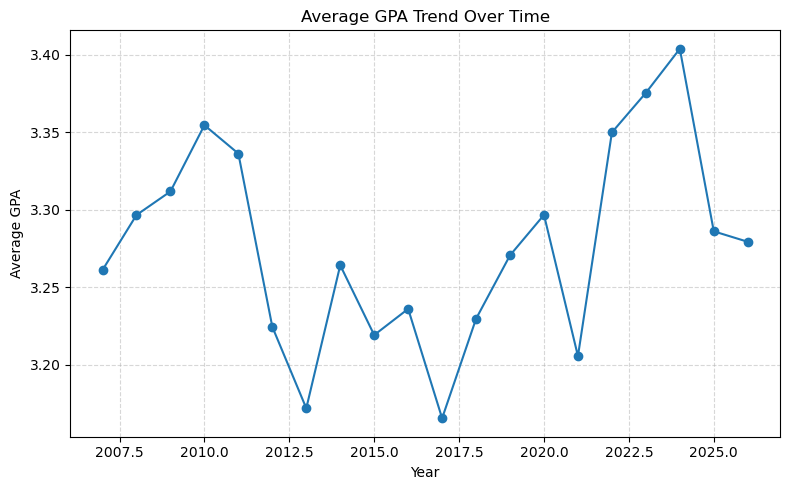

In [17]:
# Reuse continent sets from your Regional Bias section
EUROPE = {
    "Italy","France","Spain","Germany","United Kingdom","UK","Ireland","Sweden","Norway","Denmark",
    "Finland","Netherlands","Belgium","Switzerland","Austria","Portugal","Greece","Czech Republic",
    "Poland","Hungary","Croatia"
}
ASIA = {
    "Japan","South Korea","Korea, South","Republic of Korea","China","Taiwan","Thailand","Vietnam",
    "Indonesia","Philippines","Singapore","Malaysia","India","Nepal","Sri Lanka","Turkey","Israel",
    "Jordan","United Arab Emirates","UAE"
}
NORTH_AMERICA = {"United States","USA","Canada"}
LATIN_AMERICA = {
    "Mexico","Costa Rica","Peru","Guatemala","Panama","Belize","Honduras","Nicaragua","El Salvador",
    "Dominican Republic","Puerto Rico","Cuba","Colombia","Ecuador","Chile","Argentina","Brazil",
    "Uruguay","Paraguay","Bolivia"
}
AFRICA = {"South Africa","Morocco","Kenya","Tanzania","Ghana","Rwanda","Uganda","Egypt","Namibia","Botswana","Ethiopia"}
OCEANIA = {"Australia","New Zealand","Fiji"}

def to_region(country: str) -> str:
    if not isinstance(country, str):
        return "Other"
    c = country.strip()
    if c in EUROPE: return "Europe"
    if c in ASIA: return "Asia"
    if c in NORTH_AMERICA: return "North America"
    if c in LATIN_AMERICA: return "Latin America"
    if c in AFRICA: return "Africa"
    if c in OCEANIA: return "Oceania"
    return "Other"

# Ensure region exists
if "region" not in df.columns:
    df["region"] = df["country"].apply(to_region)

gpa_df = df.dropna(subset=["student_cumulative_gpa"]).copy()

# GPA Trend Over Time (Line Chart)
gpa_trend = (
    gpa_df.groupby("year_academic")["student_cumulative_gpa"]
          .mean()
          .reset_index()
          .sort_values("year_academic")
)

plt.figure(figsize=(8,5))
plt.plot(gpa_trend["year_academic"], gpa_trend["student_cumulative_gpa"], marker="o")
plt.title("Average GPA Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average GPA")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**Insights**
- The average GPA has remained relatively stable between 3.2–3.35 over the years.

- There is noticeable volatility: some dips around 2013–2015, followed by recovery and a peak around 2021–2022 (close to 3.4).

- The more recent decline (2023 onward) might suggest academic or programmatic challenges post-pandemic.

#### 5.4.2 GPA Distribution

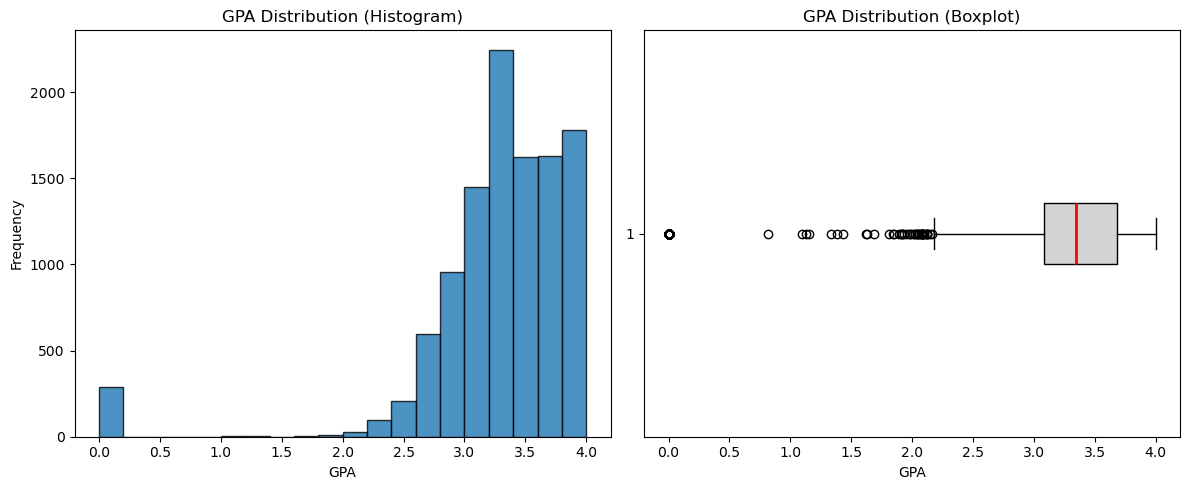

In [18]:
# GPA Distribution (Histogram + Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
axes[0].hist(gpa_df["student_cumulative_gpa"], bins=20, edgecolor="black", alpha=0.8)
axes[0].set_title("GPA Distribution (Histogram)")
axes[0].set_xlabel("GPA")
axes[0].set_ylabel("Frequency")

# Boxplot
axes[1].boxplot(
    gpa_df["student_cumulative_gpa"],
    vert=False, patch_artist=True,
    boxprops=dict(facecolor="lightgray", color="black"),
    medianprops=dict(color="red", linewidth=2)
)
axes[1].set_title("GPA Distribution (Boxplot)")
axes[1].set_xlabel("GPA")

plt.tight_layout()
plt.show()


**Insights**
- Most students cluster around the 3.0–3.7 GPA range, indicating strong overall academic performance.

- Very few students fall below 2.0, showing that low academic performance is rare.

- The boxplot confirms a tight distribution around 3.3, with some outliers on both low and high ends.

#### 5.4.3 GPA by Program Type

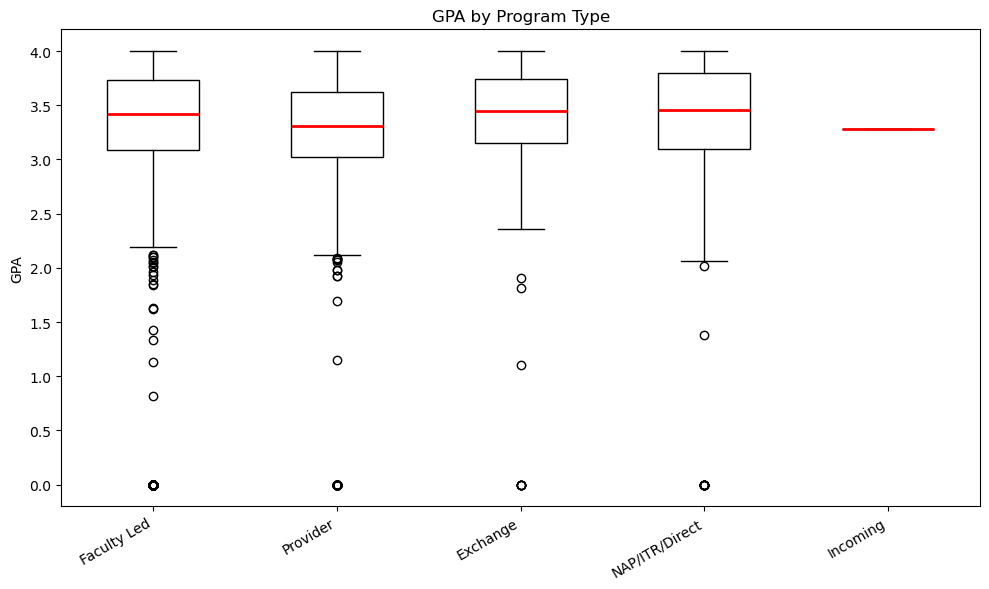

In [19]:
# GPA by Program Type (Boxplot)
prog_order = (
    gpa_df["program_type"].dropna().value_counts().index.tolist()
)
program_groups = [gpa_df.loc[gpa_df["program_type"] == p, "student_cumulative_gpa"].values
                  for p in prog_order]

plt.figure(figsize=(10,6))
plt.boxplot(
    program_groups,
    tick_labels=prog_order,
    patch_artist=True,
    boxprops=dict(facecolor="white", color="black"),
    medianprops=dict(color="red", linewidth=2)
)
plt.title("GPA by Program Type")
plt.xticks(rotation=30, ha="right")
plt.ylabel("GPA")
plt.tight_layout()
plt.show()


**Insights**
- Faculty-led and Provider programs show slightly higher median GPAs compared to Exchange and Internship programs.

- Internship participants are few in number but exhibit a flat boxplot, meaning their GPAs are clustered without much variation.

- Exchange programs show more variability, with a wider spread and more low-GPA outliers—suggesting that exchange students face more academic challenges or grading differences abroad.

#### 5.4.4 GPA bin x Region

C:\Users\shxx2\AppData\Local\Temp\ipykernel_23560\1234302010.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gpa_df.groupby(["gpa_bin","region"]).size()


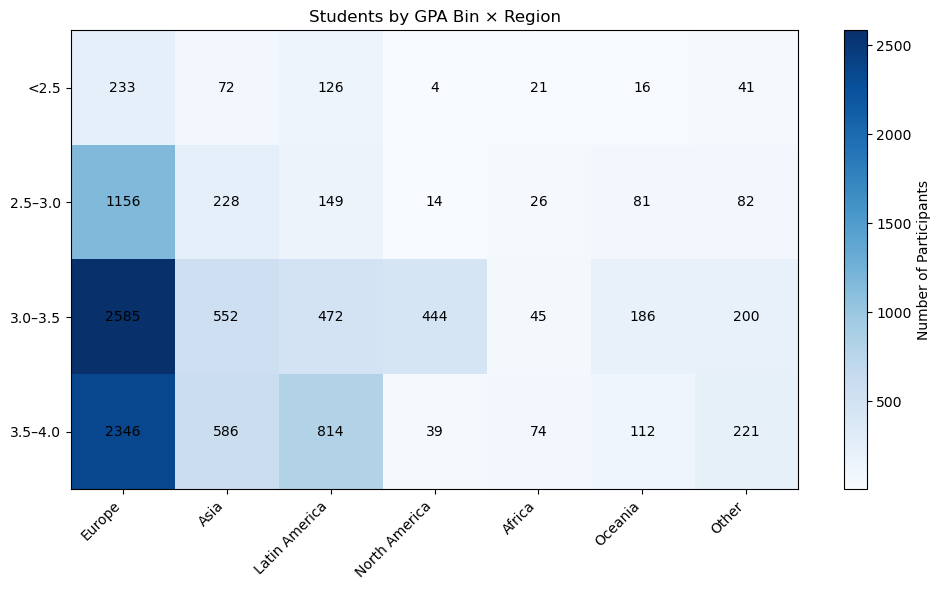

In [20]:
# GPA-bin × Region (Heatmap) 
# Define bins and labels
bins = [0, 2.5, 3.0, 3.5, 4.0]
labels = ["<2.5", "2.5–3.0", "3.0–3.5", "3.5–4.0"]

gpa_df["gpa_bin"] = pd.cut(gpa_df["student_cumulative_gpa"], bins=bins, labels=labels, include_lowest=True)

# Pivot counts
order_regions = ["Europe","Asia","Latin America","North America","Africa","Oceania","Other"]
gpa_region = (
    gpa_df.groupby(["gpa_bin","region"]).size()
          .unstack(fill_value=0)
          .reindex(index=labels, columns=[r for r in order_regions if r in gpa_df["region"].unique()] + 
                                   [c for c in gpa_df["region"].unique() if c not in order_regions])
)

# Heatmap
plt.figure(figsize=(10,6))
plt.imshow(gpa_region.values, cmap="Blues", aspect="auto")
plt.colorbar(label="Number of Participants")
plt.xticks(np.arange(len(gpa_region.columns)), gpa_region.columns, rotation=45, ha="right")
plt.yticks(np.arange(len(gpa_region.index)), gpa_region.index)
plt.title("Students by GPA Bin × Region")

# annotate cells
for i in range(gpa_region.shape[0]):
    for j in range(gpa_region.shape[1]):
        val = gpa_region.iat[i,j]
        plt.text(j, i, int(val), ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

**Insights**
- Europe dominates across all GPA bins, but especially in the 3.0–3.5 and 3.5–4.0 ranges, showing that the majority of students with higher GPAs are concentrated in European programs.

- Asia also shows strong representation across GPA bins, but with a relatively higher share in the 2.5–3.0 range compared to Europe.

- Latin America has a balanced spread, with notable presence in both the 3.0–3.5 and 3.5–4.0 bins.

- North America programs are small in volume (likely fewer abroad programs in the same region) but concentrated in mid-to-high GPAs.

- Oceania (Australia, New Zealand, Fiji) also shows a good number of students in the 3.5–4.0 bin, suggesting strong student outcomes.

- Africa has fewer participants overall, but those who join are fairly evenly spread, including high GPAs.

### 5.5 Recent Snapshot (2020-2025)

#### 5.5.1 Program Type

Recent Snapshot (2020–2025) — Program Type counts
     program_type  count
1     Faculty Led   1071
4        Provider    975
3  NAP/ITR/Direct    313
0        Exchange    188
2        Incoming    181


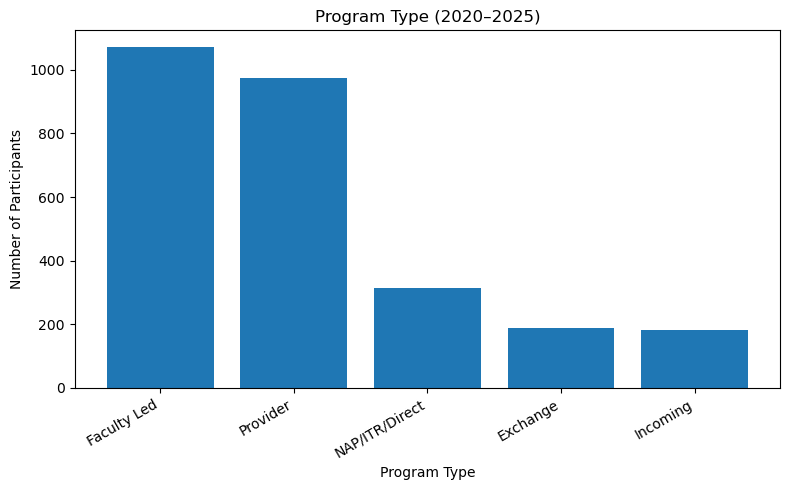

In [21]:
# Filter to recent years
recent = df[(df["year_academic"] >= 2020) & (df["year_academic"] <= 2025)].copy()

# Program Type (bar chart + table)
pt_recent = (
    recent.dropna(subset=["program_type"])
          .groupby("program_type")
          .size()
          .reset_index(name="count")
          .sort_values("count", ascending=False)
)
print("Recent Snapshot (2020–2025) — Program Type counts")
print(pt_recent)

plt.figure(figsize=(8,5))
plt.bar(pt_recent["program_type"], pt_recent["count"])
plt.title("Program Type (2020–2025)")
plt.xlabel("Program Type")
plt.ylabel("Number of Participants")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Insights**
- Faculty-Led (1,071; 39%) and Provider (975; 36%) dominate the post-2020 mix; NAP/ITR/Direct (12%) is a clear mid-tier; Exchange (7%) and Incoming (7%) are small.

- This composition suggests recovery after COVID was anchored by shorter, more structured models (faculty-led/provider) rather than traditional exchanges.

#### 5.5.2 Average GPA by Year (2020-2025)


Recent Snapshot (2020–2025) — Average GPA by Year
   year_academic  student_cumulative_gpa
0         2020.0                3.296546
1         2021.0                3.205423
2         2022.0                3.349758
3         2023.0                3.375286
4         2024.0                3.403701
5         2025.0                3.285941


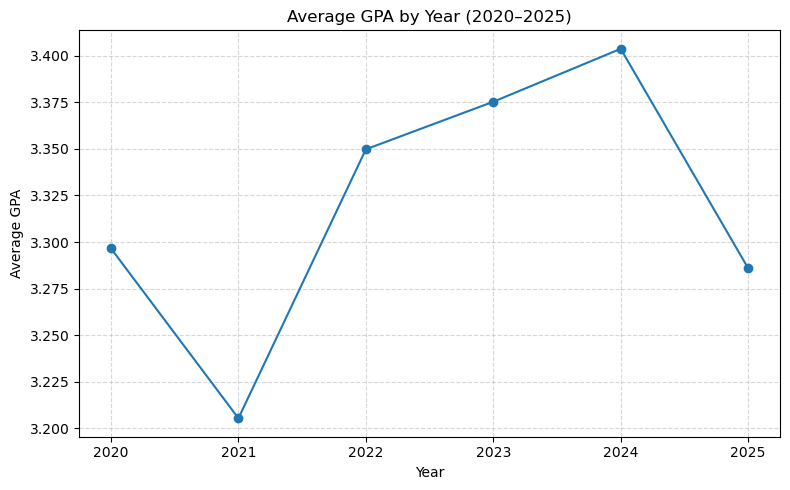

In [22]:
gpa_recent = (
    recent.dropna(subset=["student_cumulative_gpa"])
          .groupby("year_academic")["student_cumulative_gpa"]
          .mean()
          .reset_index()
          .sort_values("year_academic")
)
print("\nRecent Snapshot (2020–2025) — Average GPA by Year")
print(gpa_recent)

plt.figure(figsize=(8,5))
plt.plot(gpa_recent["year_academic"], gpa_recent["student_cumulative_gpa"], marker="o")
plt.title("Average GPA by Year (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Average GPA")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Insights**
- GPA dips in 2021 (3.21), then rebounds steadily to a peak in 2024 (3.40) before a modest pullback in 2025 (3.29).

- Overall variance is narrow (3.21–3.40), indicating stable academic performance among recent participants despite pandemic disruptions.

#### 5.5.3 Quick participation summary

In [23]:
total_recent = len(recent)
by_year = recent.groupby("year_academic").size().reset_index(name="count")
print("\nRecent Snapshot (2020–2025) — Participation counts by year")
print(by_year)


Recent Snapshot (2020–2025) — Participation counts by year
   year_academic  count
0         2020.0    322
1         2021.0     36
2         2022.0    535
3         2023.0    807
4         2024.0    737
5         2025.0    291


**Insights**
- 2021 collapses (36 students); pandemic impact. Strong rebound in 2022 (535) and 2023 (807); 2024 remains high (737).

- 2025 is lower (291), likely a partial year in the dataset; watch year-end totals to confirm trend.

### 5.6 Policy-Oriented Analysis (Equity Gaps & Suggestions)

Overall region composition (2020–2025) — expected shares
region
Europe           64.2%
Asia              9.2%
Latin America     9.1%
North America     9.0%
Other             4.6%
Oceania           2.2%
Africa            1.6%
Name: overall_share, dtype: object

major × Region — largest negative gaps (under-representation)
                            major         region  gap_pp  count  total
72                        Unknown         Europe   -61.3      6    206
16                        Biology         Europe   -25.7     40    104
57                     Psychology           Asia    -9.2      0    120
31      Hospitality Business Mgmt  Latin America    -9.1      0     89
10  Apparel Merch Design Textiles  Latin America    -9.1      0     88
66               Public Relations  Latin America    -9.1      0     96
38         International Business  Latin America    -9.1      0    106
3                      Accounting  Latin America    -9.1      0     80
32      Hospitality Business Mgmt  Nor

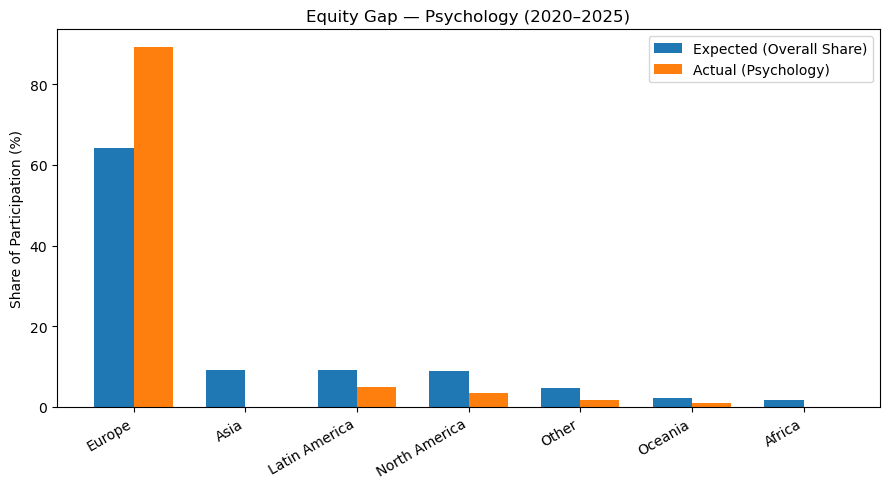

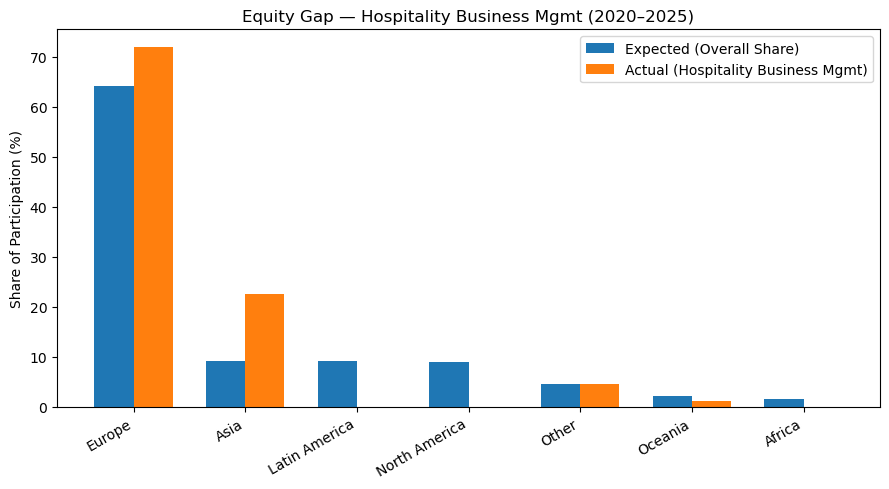

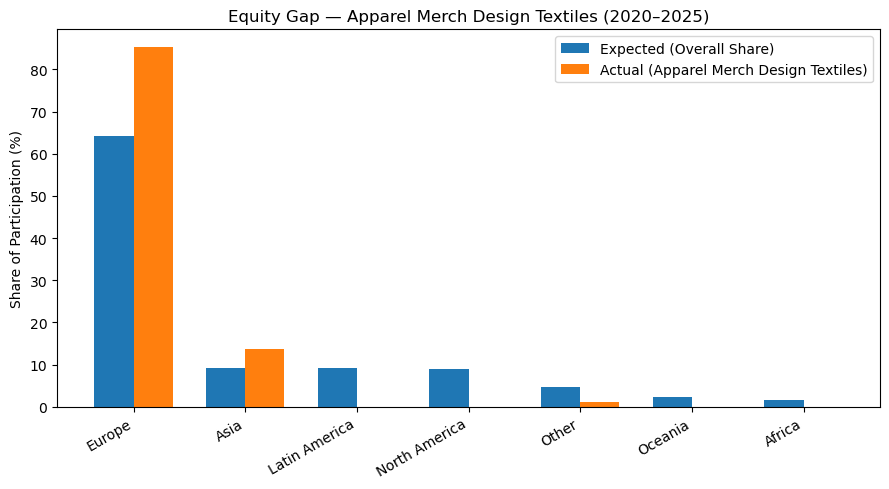


Regional diversification (HHI) by period (lower = more diversified)
year_bin
2008–2013    0.329490
2014–2019    0.395020
2020–2025    0.439756
Other        0.488494
dtype: float64


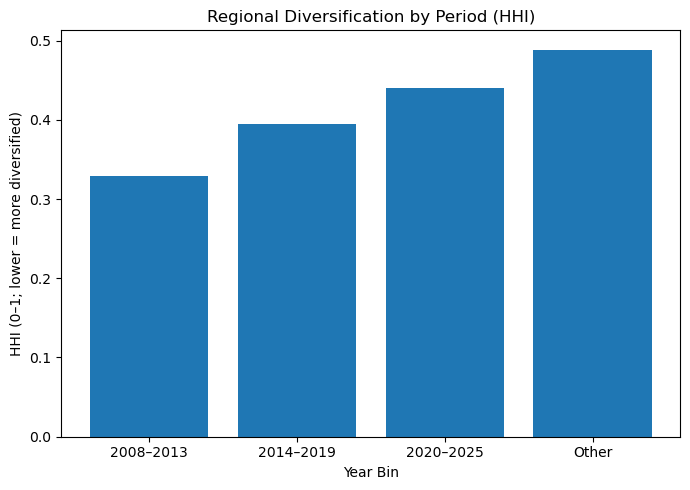

In [24]:
policy_df = df[(df["year_academic"] >= 2020) & (df["year_academic"] <= 2025)].copy()

# Overall region baseline (expected)
region_base = (
    policy_df["region"].value_counts(normalize=True)
    .rename("overall_share")
    .sort_values(ascending=False)
)
print("Overall region composition (2020–2025) — expected shares")
print((region_base * 100).round(1).astype(str) + "%")

# compute equity gaps for majors
def equity_gap_by_group(frame: pd.DataFrame, group_col: str, min_n: int = 60):
    mat = (
        frame.assign(**{group_col: frame[group_col].fillna("Unknown")})
             .dropna(subset=["region"])
             .groupby([group_col, "region"])
             .size()
             .unstack(fill_value=0)
    )
    totals = mat.sum(axis=1)
    mat = mat[totals >= min_n]
    totals = totals.loc[mat.index]

    shares = mat.div(totals, axis=0)

    base = region_base.reindex(shares.columns).fillna(0)

    gaps = shares.subtract(base, axis=1)
    gaps_pp = (gaps * 100).round(1)

    long = (
        gaps_pp.stack()
               .rename("gap_pp")
               .reset_index()
               .rename(columns={"level_0": group_col, "level_1": "region"})
    )

    long["count"] = long.apply(lambda r: mat.loc[r[group_col], r["region"]], axis=1)
    long["total"] = long[group_col].map(totals)

    top_region = shares.idxmax(axis=1)
    top_share = shares.max(axis=1)
    hhi = (shares ** 2).sum(axis=1)
    summary = pd.DataFrame({
        group_col: shares.index,
        "total": totals.values,
        "top_region": top_region.values,
        "top_region_share_%": (top_share.values * 100).round(1),
        "hhi": hhi.values.round(3)
    }).sort_values(["hhi","total"], ascending=[False, False])

    return mat, shares, gaps_pp, long.sort_values("gap_pp"), summary

major_col = "major_std" if "major_std" in policy_df.columns else "major"
maj_counts, maj_shares, maj_gaps_pp, maj_long, maj_summary = \
    equity_gap_by_group(policy_df, major_col, min_n=60)

print(f"\n{major_col} × Region — largest negative gaps (under-representation)")
print(maj_long.head(15))

# Pick top N under-represented (by most negative gap) outside Europe to visualize
focus = maj_long[(maj_long["region"].isin(["Asia","Latin America","Africa","Oceania","North America","Other"]))] \
                 .sort_values("gap_pp").head(3)[major_col].unique().tolist()

for m in focus:
    actual = maj_shares.loc[m].reindex(region_base.index).fillna(0) * 100
    expected = region_base.reindex(actual.index).fillna(0) * 100
    idx = np.arange(len(actual.index)); width = 0.35

    plt.figure(figsize=(9,5))
    plt.bar(idx - width/2, expected.values, width, label="Expected (Overall Share)")
    plt.bar(idx + width/2, actual.values, width, label=f"Actual ({m})")
    plt.xticks(idx, actual.index, rotation=30, ha="right")
    plt.ylabel("Share of Participation (%)")
    plt.title(f"Equity Gap — {m} (2020–2025)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Temporal regional diversification evidence (bins)
bin_reg = (
    df.dropna(subset=["year_bin"])
      .groupby(["year_bin","region"]).size()
      .unstack(fill_value=0)
      .sort_index()
)
bin_shares = bin_reg.div(bin_reg.sum(axis=1), axis=0)
bin_hhi = (bin_shares**2).sum(axis=1).sort_index()

print("\nRegional diversification (HHI) by period (lower = more diversified)")
print(bin_hhi)

plt.figure(figsize=(7,5))
plt.bar(bin_hhi.index.astype(str), bin_hhi.values)
plt.title("Regional Diversification by Period (HHI)")
plt.xlabel("Year Bin")
plt.ylabel("HHI (0–1; lower = more diversified)")
plt.tight_layout()
plt.show()


1. Interpreting the Results

- From 2020–2025, Europe accounts for 64% of all study abroad destinations, while Asia, Latin America, and North America each make up only around 9–10%.

- By major:

    - Psychology students study abroad in Asia far less than expected.

    - Hospitality Business Management and Apparel Design/Textiles students study abroad in Latin America and North America less often.

    - Other majors (Marketing, Biology, Accounting) also send relatively few students outside of Europe.

- The charts confirm that for many majors, study abroad opportunities are strongly concentrated in Europe, while destinations in Asia, Latin America, and Africa are under-used.

2. Explaining the Over-Representation of Europe

- Program structures and partnerships: WSU likely has more established exchange agreements, partner institutions, or logistical support in Europe, making it the most accessible option.

- Perceived safety and familiarity: Students and families may see Europe as a “safer” or “easier” destination compared to other regions.

- Major-specific appeal: Programs in Hospitality, Design, or Psychology may be particularly strong or attractive in Europe, reinforcing the imbalance.

- Institutional history: Long-standing European connections and alumni networks may make it harder for newer destinations to grow.

3. Diversity Over Time

    The HHI index (measuring concentration of destinations) shows a clear trend:

- 2008–2013: more balanced use of regions.

- 2014–2019 and 2020–2025: increasing concentration in Europe, meaning fewer students explore beyond that region.

    Instead of becoming more globally diverse, WSU’s study abroad programs have become more Eurocentric.
Possible reasons:

- Program growth focused mainly on Europe, not equally in Asia, Africa, or Latin America.

- Recruitment and marketing messages that highlight Europe more strongly.

- Barriers such as language, cost, or visa complexity making non-European regions less accessible.

4. Why promoting diversity policies is necessary

    The mission of Education Abroad is to promote global awareness and engagement and to create equitable opportunities for all identities. If most students only go to Europe, they miss the chance to engage with the wider world—cultures, economies, and perspectives in Asia, Africa, and Latin America.

    Promoting diversity in destinations is therefore essential because:

- It ensures students gain a truly global perspective, not just a European one.

- It provides equitable access to under-represented regions, in line with the department’s commitment to diversity.

- It helps prepare WSU students for a world where future careers and collaborations will increasingly depend on connections beyond Europe, especially in Asia, Latin America, and Africa.

    Without deliberate policies, the imbalance will continue, and the vision of preparing students for a sustainable and peaceful world will be harder to achieve.

5. Policy Suggestions

- Recruitment & scholarships: Target support for programs in Asia, Latin America, and Africa.

- Expand access beyond Europe: Build more partnerships and exchanges outside Europe.

- Make programs more global: Market the unique academic and cultural value of non-European destinations.

- Track progress: Monitor destination diversity by major and set goals to reduce over-reliance on Europe.

## 6. Reflection
- I would start with a tighter research question and explicit hypothesis to guide the flow; this iteration leaned on descriptive work with light prescriptive suggestions rather than diagnostic or predictive analysis.

- The hardest part was cleaning, especially the major field. Abbreviations, typos, legacy program names, and inconsistent formats meant that even after large scale standardization many records still fell into Other, which required multiple passes that combined rule based mapping with manual review.

- I would backfill missing college values by mapping standardized majors to their current college names, while documenting exceptions across catalog changes. This would recover many nulls and enable more meaningful college level comparisons.

- I ran into missing data and changes in how the data was structured over time, like new columns appearing in later years. This reminded me that real world analysis requires going back and forth to refine the work, keeping clear notes about what I did and why, and double checking results, not just building models.

- Next time I would pair the visuals with deeper statistical testing to confirm whether observed differences are meaningful.

## 7. Further Analysis Ideas

- Ambassador Diversity Audit: Compare ambassador demographics and academic backgrounds to the participant pool. If certain groups are missing, recruit targeted ambassadors to bridge representation gaps.
- Scholarship Impact Study: Merge with scholarship award data to see if financial aid correlates with higher participation among historically under-represented groups and use this to inform funding priorities.
- Program Outcome Tracking: Follow up with participants on skills, career paths, or further study; identify which program types yield the strongest long-term benefits. (this could be done with open-ended questions survey)
- Geographic Risk & Opportunity Analysis: Combine destination data with safety indexes and partner availability to diversify options while managing risk.
- Demand Prediction: Use past trends by year, college, and program type to predict future demand and adjust program capacity and marketing strategies accordingly.
- Scholarship & Financial Aid Effects: Merge award data to test whether aid increases participation from low-income or underrepresented groups. Estimate effect sizes by college/major and year bins to guide funding allocations and outreach timing.
- Add campus enrollment denominators by college/major to compute true participation rates.